怎么找到
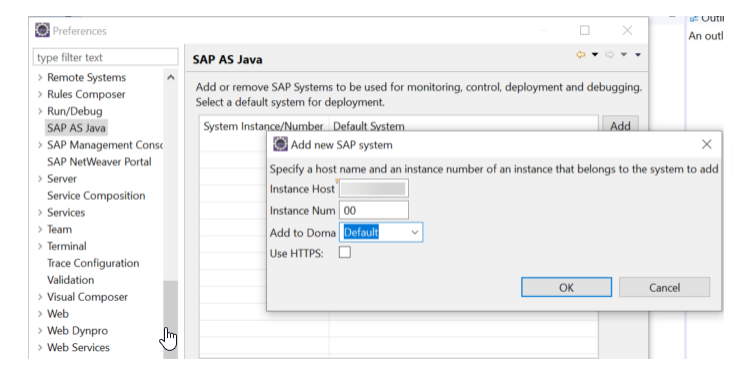



在 NWDS 中配置这个页面时，你需要输入 SAP PO 服务器的信息。这些信息通常由公司的 SAP Basis 团队掌握。如果你需要自己查找，可以通过以下几种方式获取：

1. 从 SAP 登录界面查看（最直接）
如果你有访问 SAP PO 系统界面（例如通过 SAP GUI 或浏览器访问 /nwa）的权限：

查看登录服务器信息：在登录 SAP GUI 时，查看“连接参数（Connection Parameters）”界面。

Instance Host：通常就是你登录的服务器 IP 地址或 Hostname。

Instance Number：在登录配置中通常会明确列出，例如 00, 01, 02 等。

2. 通过 SAP NetWeaver Administrator (NWA) 查看
这是最标准的查找方式：

在浏览器中打开 PO 系统的 NWA 管理界面（通常地址是 http://<Host>:<Port>/nwa）。

进入 Configuration -> Infrastructure -> Java System Properties。

在 Instances 选项卡下，你可以清晰地看到当前系统所有的实例及其编号（Instance Number）和对应的主机名（Host）。

3. 查看服务器端的配置文件（如果您有系统访问权限）
如果你可以登录到 PO 服务器的操作系统（OS 层级），可以直接查看配置文件：

路径：/usr/sap/<SID>/instance.properties 或查看 /sapmnt/<SID>/profile 下的 profile 文件。

在这些文件中搜索 j2ee/instance 或 SAPSYSTEM，对应的数值就是你的 Instance Number。

4. 咨询 Basis 同事（最推荐）
这是最靠谱的方法。你可以直接问 Basis 同事：

“你好，我在配置 NWDS 连接 PO 系统（SID 为 XXX），请问系统的 Instance Host 和 Instance Number 是多少？我需要配置监控和调试功能。”

Basis 同事通常会直接提供给你，因为这些信息涉及服务器的网络架构，直接配置错误可能导致连接失败或账号锁定。

配置建议
Instance Host：输入实际的 IP 地址或完整的域名（FQDN）。

Instance Num：通常是两位数字（如你的图片中写了 00）。

Use HTTPS：如果你的 PO 系统开启了安全传输，记得勾选此项，并确认端口（默认 HTTPS 是 5xx01，HTTP 是 5xx00，xx 是实例号）。

你目前的网络环境是否能够直接访问到那台服务器？如果输入后点击 OK 报错，通常是因为网络防火墙没有开放该端口。


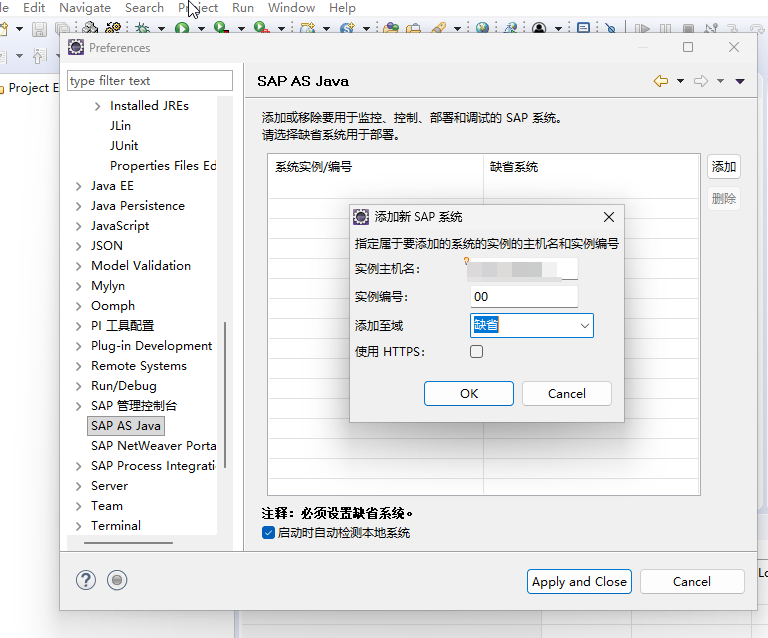


上面一步走完需要下面这步

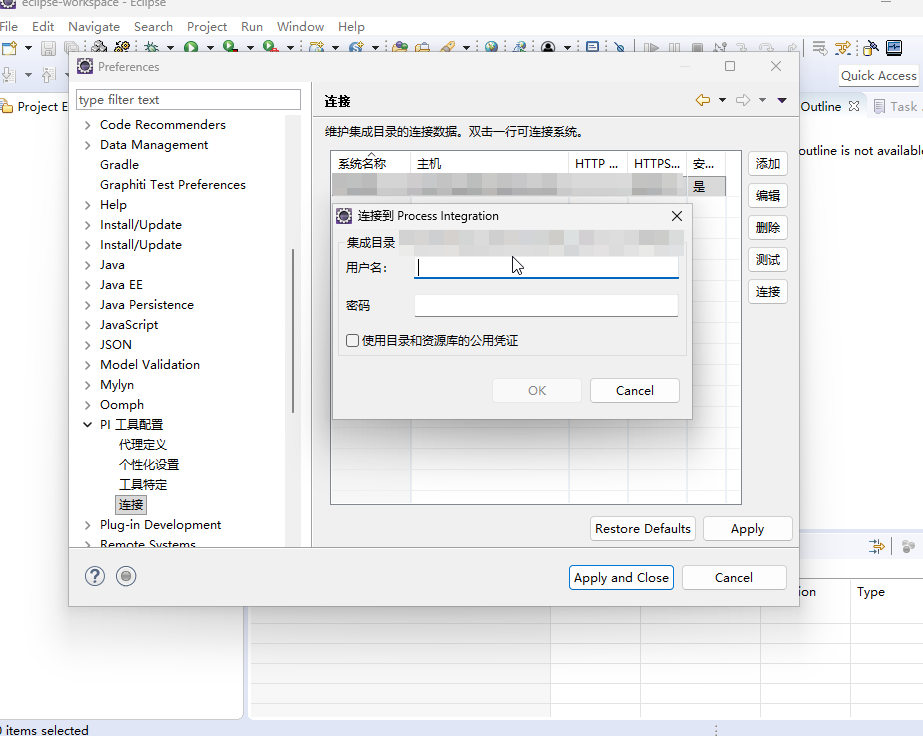

连接 测试下

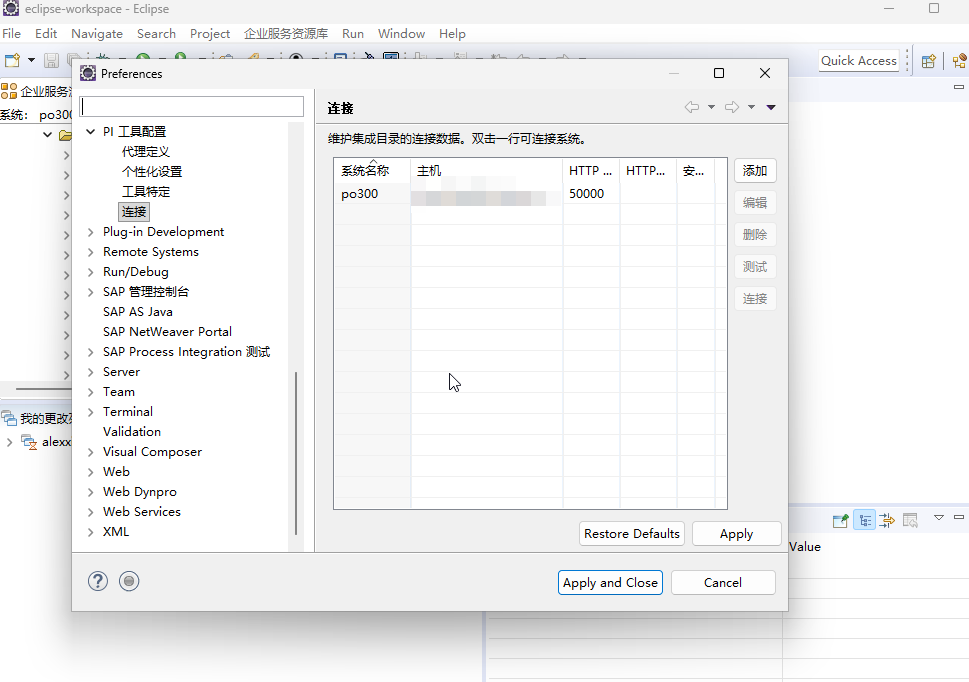


找到下面的配置
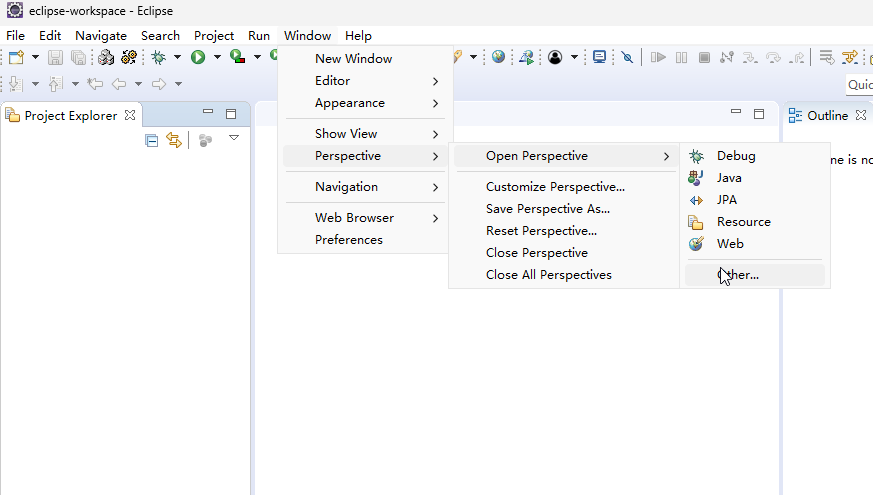

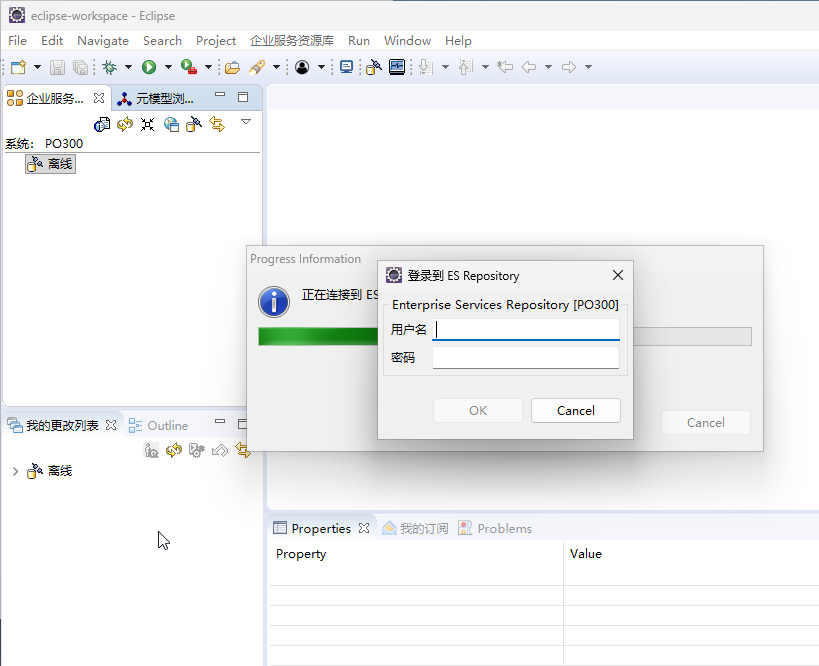


配置好的结果
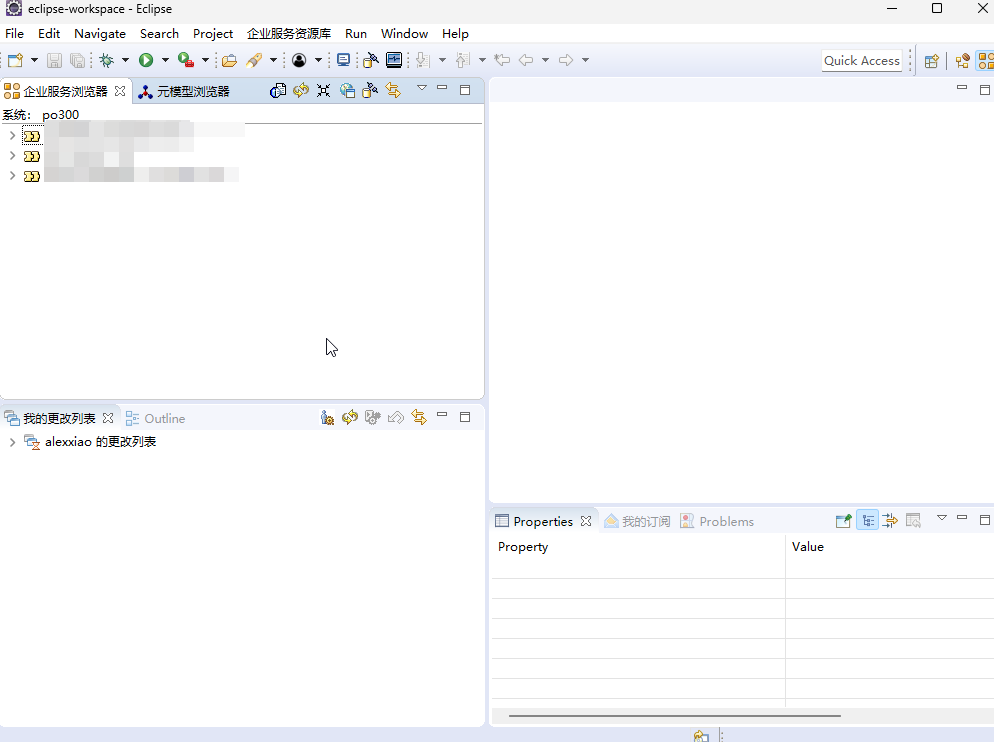




20260617 没有时间整了 先放这里 后面更新

如果出现了乱码
操作路径：Window -> Preferences -> General -> Workspace
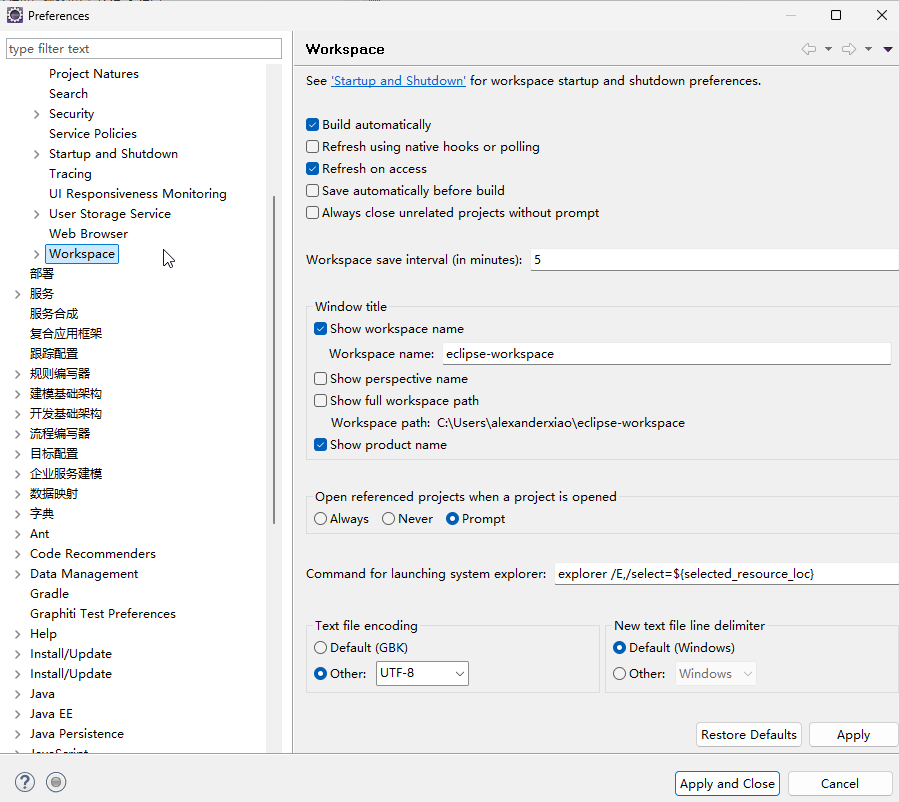



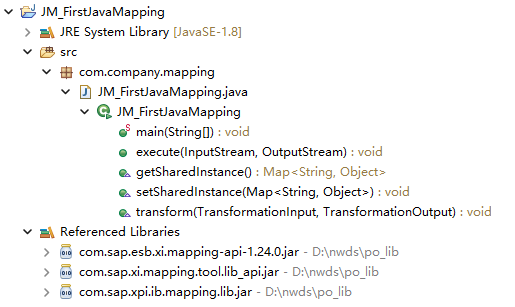


需要导入这三个包  服务器文件目录下面使用这个      

路径 /usr/sap/<SID>/<Instance_ID>/j2ee/cluster/bin/ext/ 中带有尖括号的部分是变量，在真实的服务器上你需要替换成具体的名字：

<SID> (System ID)：SAP 系统的三位字母/数字标识。比如如果你们的系统叫 PO1，那这层文件夹就叫 PO1。

<Instance_ID> (实例 ID)：通常是以 J 开头加上两位数字，或者是 JC 加数字。比如 J00、J01 或 JC00。


find /usr/sap/<SID>/<Instance_ID>/j2ee/cluster/bin/ext/ -name "*mapping*api*.jar"

把上面图片三个文件使用find 语句找下，然后下载到本地  然后



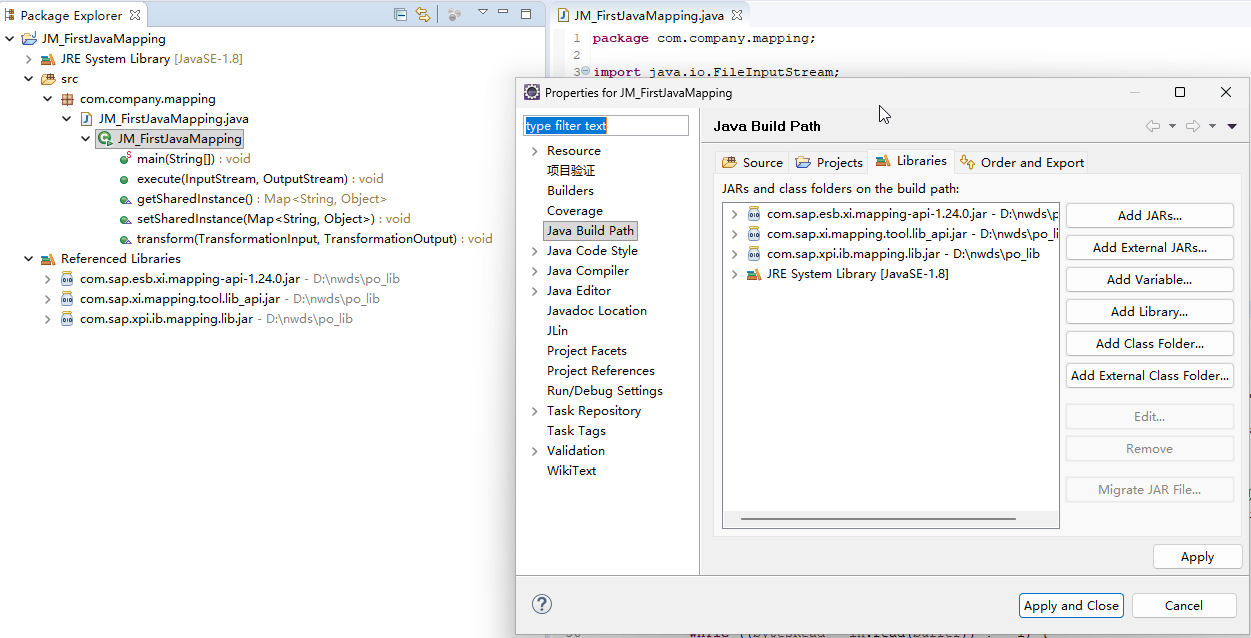


每个机子的版本不一样，一定要从自己的po服务器下载，不要从网上下载，不然会报错 （我猜测的）


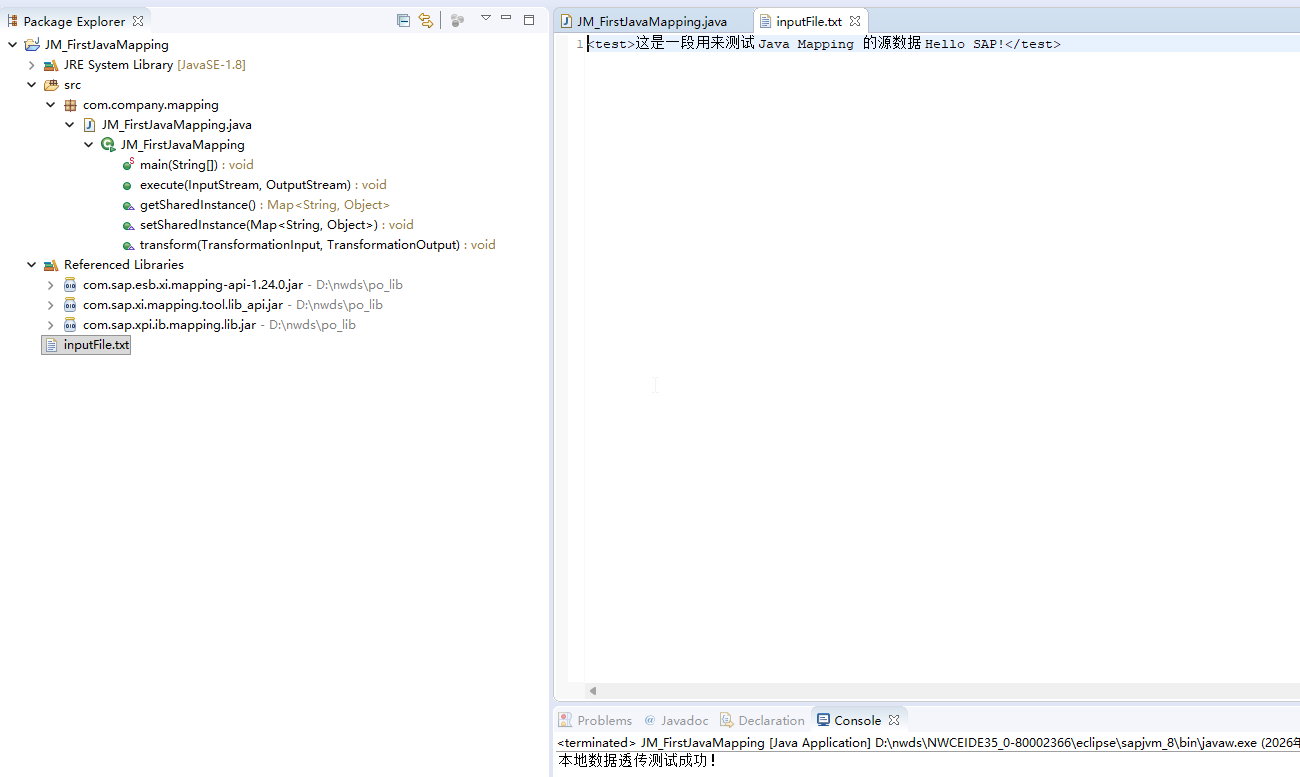

记得加一个文件 inputFile.txt


给整体打包下来 

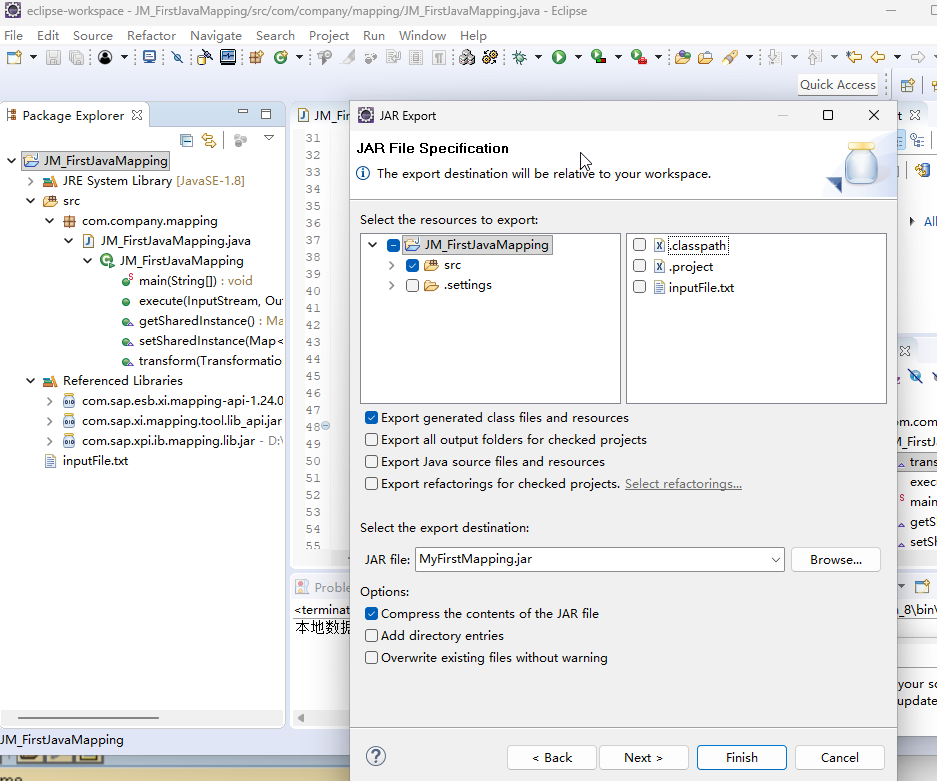


会得到一个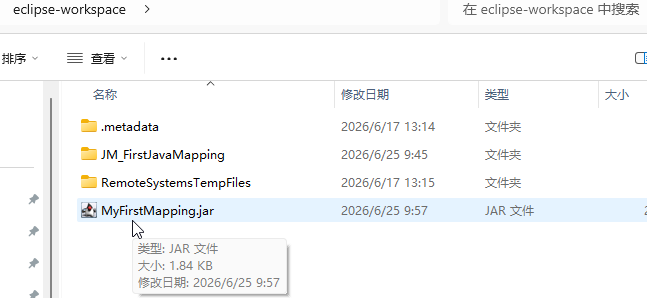


重新新建一个namesapce  


然后  我再导入试试


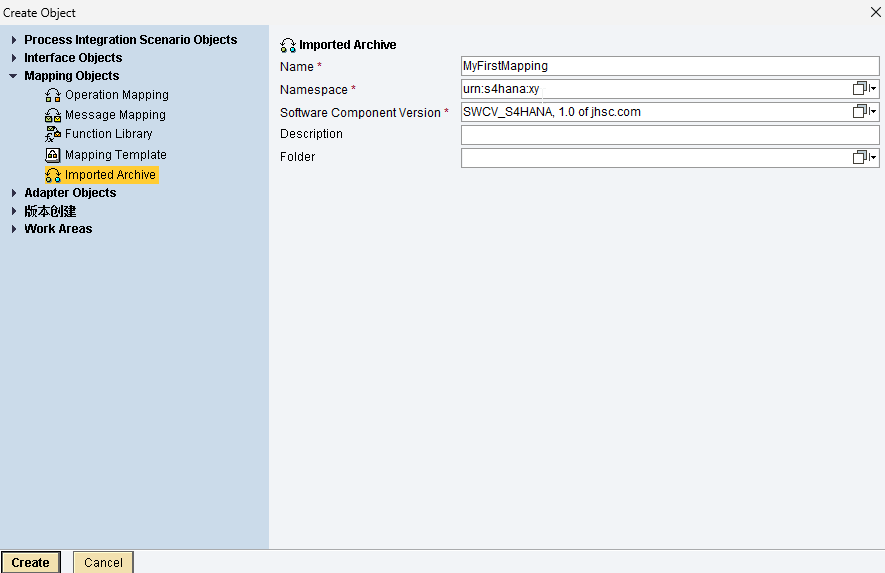


把jdk版本直接改成1.8

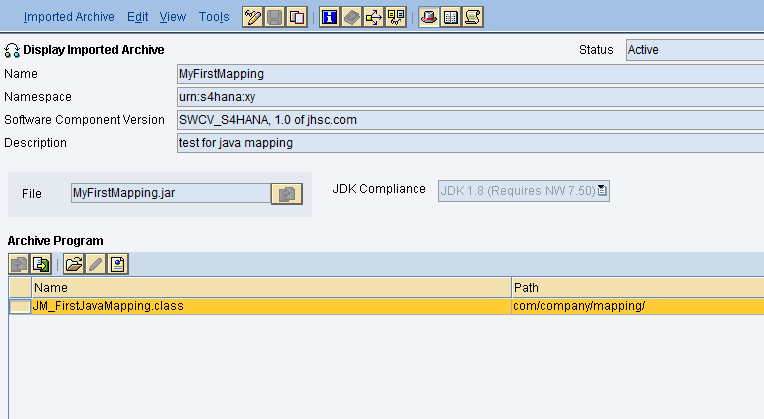


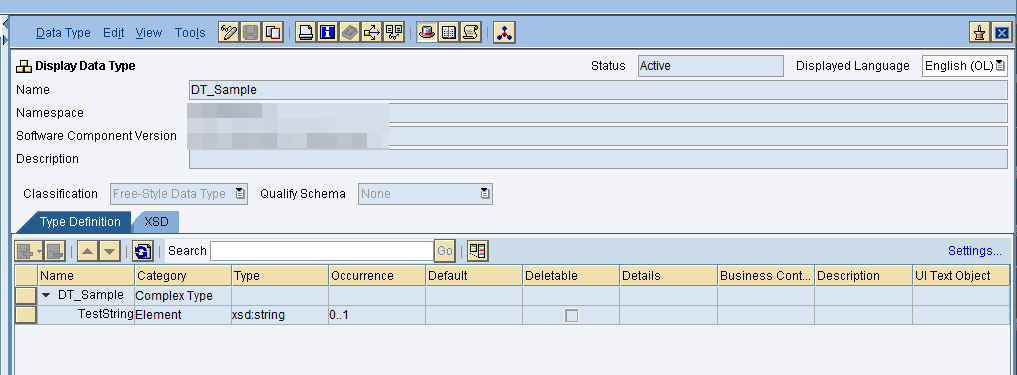

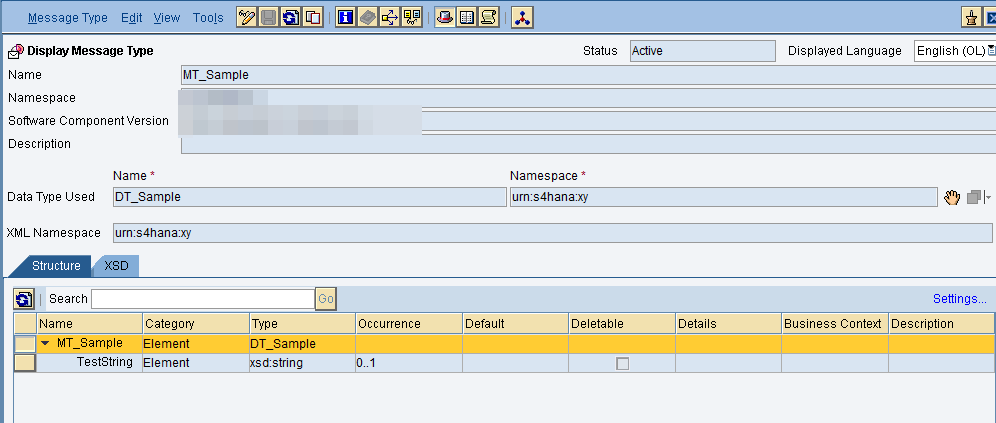


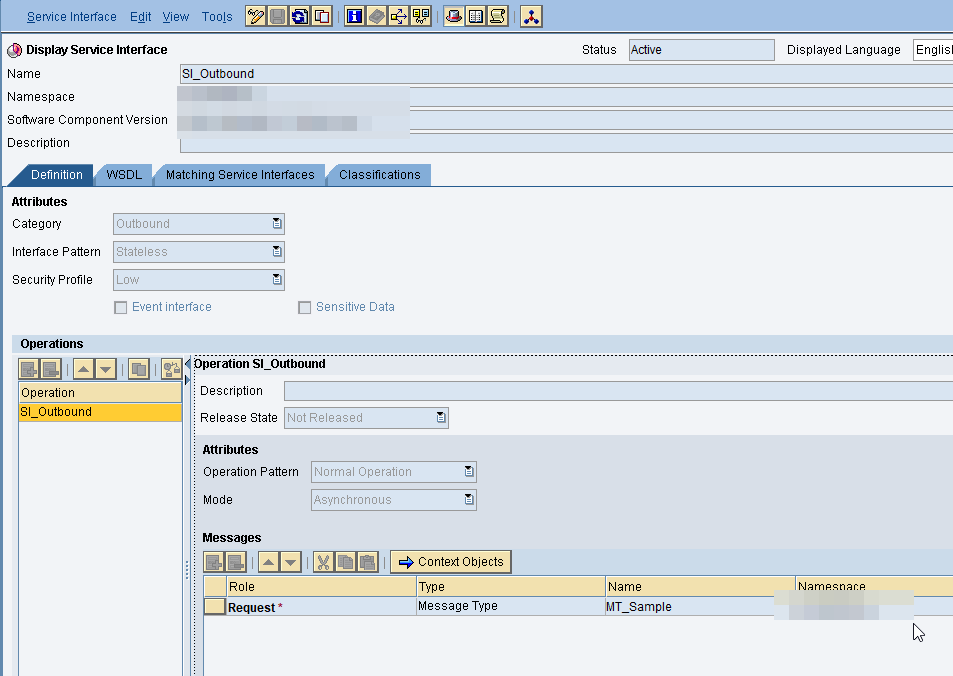


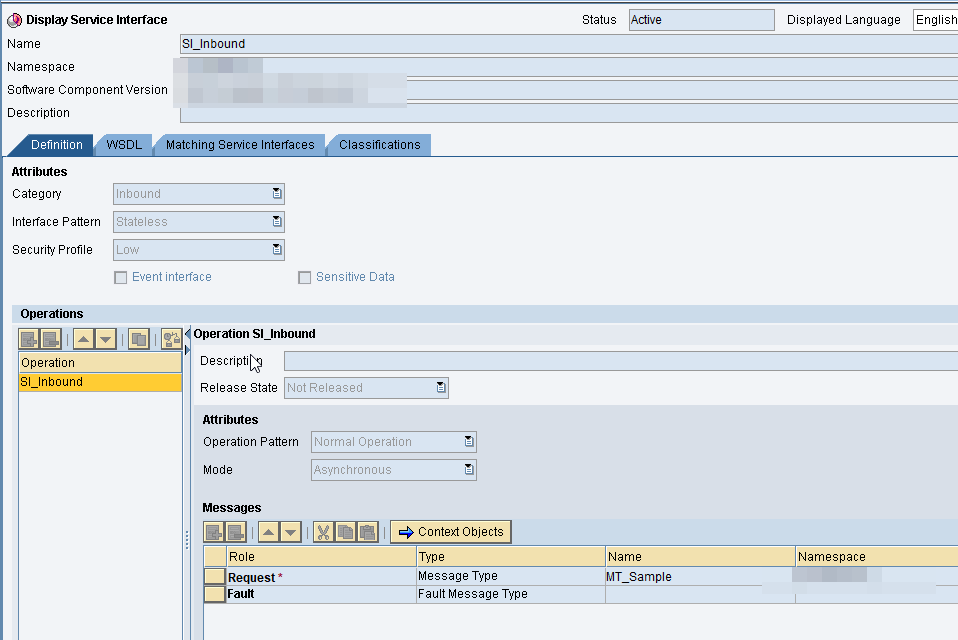

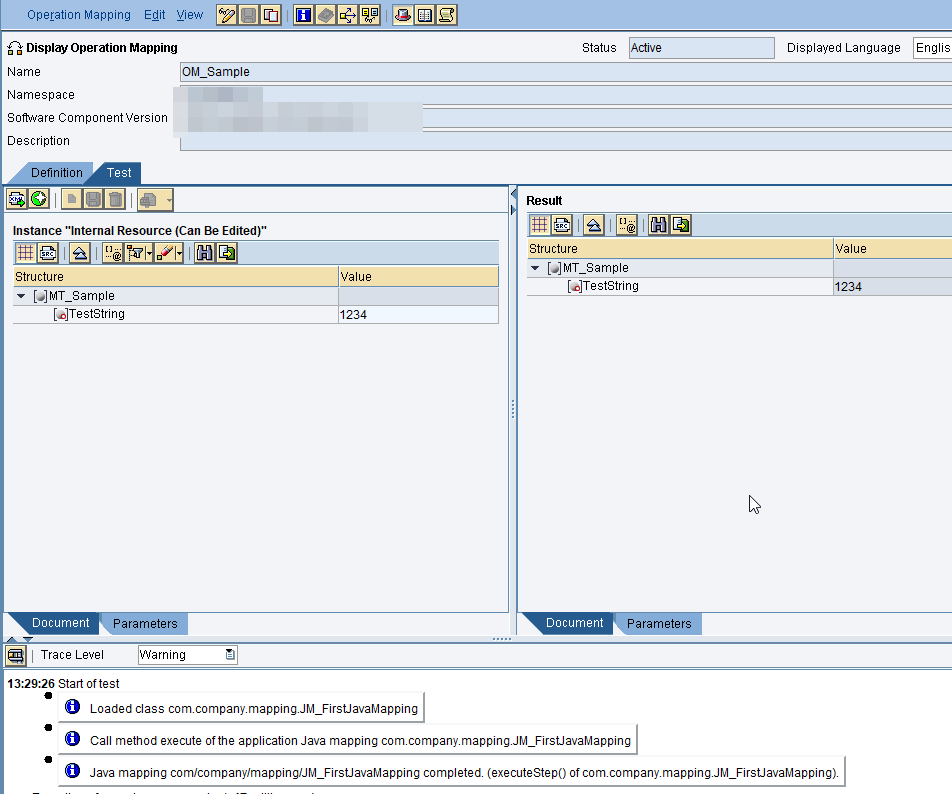

这是一个标准的 **SAP PI/PO（Process Integration / Process Orchestration）Java 映射**程序，作用是把输入消息的字节流**原封不动地复制到输出**，也就是常说的“透传映射”。下面逐部分解释。

---

## 1. 类定义与继承
```java
public class JM_FirstJavaMapping extends AbstractTransformation
```
- 必须继承 `com.sap.aii.mapping.api.AbstractTransformation`，这是所有 Java 映射的基类。
- 注释里强调“不能加 `abstract`”，是因为 PO 运行时会通过反射创建这个类的实例，如果类是抽象的，就会实例化失败。

---

## 2. `transform` 方法 —— PO 运行时的入口
```java
public void transform(TransformationInput in, TransformationOutput out) 
        throws StreamTransformationException
```
- PO 引擎在处理消息时，会自动调用这个方法。
- `TransformationInput` 提供了**输入消息的流**（通过 `in.getInputPayload().getInputStream()`）。
- `TransformationOutput` 提供了**输出消息的流**（通过 `out.getOutputPayload().getOutputStream()`）。
- 方法内部将这两个流传给自定义的 `execute` 方法，统一处理，并在异常时包装成 `StreamTransformationException` 抛出，这样 PO 可以记录错误并处理。

---

## 3. `execute` 方法 —— 实际的数据处理逻辑
```java
public void execute(InputStream in, OutputStream out) throws StreamTransformationException
```
这里就是**透传的实现**：

```java
byte[] buffer = new byte[8192];
int bytesRead;
while ((bytesRead = in.read(buffer)) != -1) {
    out.write(buffer, 0, bytesRead);
}
out.flush();
```
- 用 8 KB 的缓冲区循环读取输入流，并立即写入输出流。
- 注释提到的“不要用单字节读取”是性能常识：单字节读取会导致极多次 IO 操作，极大降低吞吐量。使用 `byte[]` 缓冲区一次读/写一个块，速度可以提高成千上万倍。
- 读完所有数据后，调用 `out.flush()` 确保缓冲区中的内容全部写出。

**这样设计的好处**：`execute` 的输入输出是标准的 Java IO 流，因此既可以被 PO 的 `transform` 方法调用，也可以被本地 `main` 方法直接调用，方便在没有服务器的情况下调试。

---

## 4. `main` 方法 —— 本地测试
```java
public static void main(String[] args) { ... }
```
- 这是完全**独立于 PO 运行时**的测试入口。
- 它创建文件输入流 `inputFile.txt` 和文件输出流 `outputFile1.txt`，然后直接调用 `execute` 方法。
- 如果你的 Eclipse/IDE 项目根目录下有 `inputFile.txt`，运行这个 `main` 方法后，就会生成一个内容完全一样的 `outputFile1.txt`，并在控制台输出“本地数据透传测试成功！”。
- 注释特意提醒**测试后关闭流**（`fin.close(); fout.close();`），这是良好的资源释放习惯，避免文件句柄泄漏。

---

## 5. `getSharedInstance` 与 `setSharedInstance`
```java
public Map<String, Object> getSharedInstance() { return null; }
public void setSharedInstance(Map<String, Object> arg0) { }
```
- 这两个方法是 `AbstractTransformation` 接口的一部分，用于在**同一个映射的多次调用之间共享数据**（比如缓存一些重型资源）。
- 这里只是空实现，表示当前映射不需要共享任何实例数据。

---

## 总结
- **核心功能**：输入什么，就输出什么（1:1 复制字节流）。
- **代码结构**：遵循 SAP 标准 Java 映射模式——继承 `AbstractTransformation`，实现 `transform`，并把核心逻辑抽离到可单独测试的方法中。
- **性能考虑**：使用 8 KB 缓冲区批量读写，避免逐字节操作。
- **可测试性**：通过 `main` 方法可以在本地 IDE 直接运行和调试，无需部署到 PO 服务器。

如果你后续要在这个基础上做**真正的数据转换**（比如 XML 解析、字段映射、内容修改等），只需要修改 `execute` 方法的内部逻辑，把“直接复制流”换成你需要的处理即可。

In [ ]:
package com.company.mapping;

import java.io.FileInputStream;
import java.io.FileOutputStream;
import java.io.InputStream;
import java.io.OutputStream;
import java.util.Map;

import com.sap.aii.mapping.api.AbstractTransformation;
import com.sap.aii.mapping.api.StreamTransformationException;
import com.sap.aii.mapping.api.TransformationInput;
import com.sap.aii.mapping.api.TransformationOutput;

// 核心修改 1：必须去掉 abstract 关键字，否则类无法被实例化
public class JM_FirstJavaMapping extends AbstractTransformation {

    // PO 系统在运行时，会自动调用这个 transform 方法
    @Override
    public void transform(TransformationInput in, TransformationOutput out) throws StreamTransformationException {
        try {
            // 从 TransformationInput 获取输入流，传入到你自己的 execute 方法中处理
            execute(in.getInputPayload().getInputStream(), out.getOutputPayload().getOutputStream());
        } catch (Exception ee) {
            throw new StreamTransformationException("Mapping failed: " + ee.getMessage(), ee);
        }
    }
    
    // 提取出来的核心处理逻辑（这样写的好处是既能被 PO 调用，也能被 main 方法在本地调用测试）
    public void execute(InputStream in, OutputStream out) throws StreamTransformationException {
        try {
            // 核心修改 2：千万不要用单字节读取！改用 byte 数组作为缓冲区
            byte[] buffer = new byte[8192];
            int bytesRead;
            
            // 每次读取 8KB 的数据包，性能比单字节读取快几千倍
            while ((bytesRead = in.read(buffer)) != -1) {
                out.write(buffer, 0, bytesRead);
            }
            
            out.flush();
            
        } catch (Exception ee) {
            throw new StreamTransformationException("Execute failed: " + ee.getMessage(), ee);
        }
    }
    
    // 本地测试方法（传到 SAP PO 服务器上时，这个方法会被系统忽略，但留着方便你本地打断点调试）
    public static void main(String[] args) {
        try {
            // 提示：确保你的 Eclipse 项目根目录下有一个名为 inputFile.txt 的文件，否则本地运行会报找不到文件
            FileInputStream fin = new FileInputStream("inputFile.txt");
            FileOutputStream fout = new FileOutputStream("outputFile1.txt");
            
            JM_FirstJavaMapping instance = new JM_FirstJavaMapping();
            instance.execute(fin, fout);
            
            System.out.println("本地数据透传测试成功！");
            
            // 核心修改 3：本地测试完毕后，务必养成关闭流的好习惯
            fin.close();
            fout.close();
            
        } catch (Exception ee) {
            ee.printStackTrace();
        }
    }

	@Override
	public Map<String, Object> getSharedInstance() {
		// TODO Auto-generated method stub
		return null;
	}

	@Override
	public void setSharedInstance(Map<String, Object> arg0) {
		// TODO Auto-generated method stub
		
	}
}